# Q1 — Pré-treino contínuo (DOM-PI)

**Grupo 2:** Francisco Cosme Monteiro Xavier, Heitor Andrade Moura, Isaac Augusto Santana Brito e João Pedro Monteiro da Silva Barros

- **Objetivo:** adaptar o LLM ao domínio dos Diários Oficiais dos Municípios do PI e medir o ganho.
- **Método:** treino contínuo (previsão do próximo token) com LoRA; mede **entropia cruzada, perplexidade e acurácia de token** (+ MCQ) ANTES e DEPOIS no mesmo held-out.
- **Modelo / Dados:** Qwen3 (1.7B p/ teste → 4B oficial) · `gutoportelaa/dom-pi-corpus-2025`.
- **Saída:** adapter em `heitor-am/qwen3-<size>-dompi-pretrain`.
- **Como rodar (Colab):** Runtime → GPU T4 → escolha `MODE` ("smoke" ou "oficial") → Run all.
- **Packing:** o corpus é concatenado e quebrado em blocos de 1024 tokens (aproveita ~todos os tokens).

## Passo a passo
1. Carrega o Qwen3 em 4-bit.
2. Monta o corpus DOM-PI, EXCLUINDO do treino os documentos-fonte do benchmark (evita contaminação).
3. Mede perplexidade, entropia cruzada, acurácia de token e MCQ ANTES (held-out).
4. Faz o pré-treino contínuo com LoRA (packing em blocos de 1024 tokens).
5. Mede as mesmas métricas DEPOIS, publica o adapter e salva results_q1.json.

### Setup — montar o Google Drive e entrar na pasta (persiste os resultados)

In [1]:
# Necessário p/ os results_qN.json caírem no Drive (não no /content efêmero). Fora do Colab, pule.
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/ufpi/topics-in-ai/final-project

Mounted at /content/drive
/content/drive/MyDrive/ufpi/topics-in-ai/final-project


### Instalação

In [2]:
!pip -q install -U transformers accelerate peft datasets bitsandbytes
!pip -q install -U pyarrow    # compat com datasets; se der "IpcReadOptions size changed", REINICIE a sessao e rode de novo
!pip -q uninstall -y torchao   # evita conflito de versão (PEFT exige torchao>=0.16; não usamos)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 16.3 MB/s eta 0:00:00


### Login no Hugging Face (cole seu token WRITE quando pedir; NÃO escreva no código)

In [10]:
from huggingface_hub import notebook_login
notebook_login()

### Modelo base

In [5]:
import os, torch, math
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"   # reduz fragmentação
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

# ---- Seletor de modo (troque aqui) ----
MODE = "oficial"        # "smoke" (rápido, valida o pipeline) ou "oficial" (resultado p/ entrega)
CFG = {  # max_steps limita o treino p/ caber na T4 grátis (4B inteiro levaria horas); -1 = sem teto
    "smoke":   {"model": "Qwen/Qwen3-1.7B", "n_train": 600,  "quality_A": False, "epochs": 1, "max_steps": -1},
    "oficial": {"model": "Qwen/Qwen3-4B",   "n_train": 800,  "quality_A": True,  "epochs": 1, "max_steps": 50},
}[MODE]
MODEL_ID, N_TRAIN, QUALITY_A, EPOCHS, MAX_STEPS = (
    CFG["model"], CFG["n_train"], CFG["quality_A"], CFG["epochs"], CFG["max_steps"])
print(f"MODE={MODE} | modelo={MODEL_ID} | docs_treino={N_TRAIN} | max_steps={MAX_STEPS}")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = "fp16"   # "fp16" (T4, recomendado) ou "float32" (mais memoria; use so se fp16/bf16 quebrar)
_CDT = torch.float16 if DTYPE == "fp16" else torch.float32
_FP16 = (DTYPE == "fp16")
bnb = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_quant_type="nf4",
                         bnb_4bit_compute_dtype=_CDT, bnb_4bit_use_double_quant=True)
tok = AutoTokenizer.from_pretrained(MODEL_ID)
if tok.pad_token is None:
    tok.pad_token = tok.eos_token
model = AutoModelForCausalLM.from_pretrained(MODEL_ID, quantization_config=bnb, device_map="auto")

MODE=oficial | modelo=Qwen/Qwen3-4B | docs_treino=800 | max_steps=50


config.json:   0%|          | 0.00/726 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/9.73k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

...

model.safetensors.index.json:   0%|          | 0.00/32.8k [00:00<?, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

### Corpus DOM-PI (HF) -> split treino/avaliação (SEM contaminação do benchmark)

In [6]:
from datasets import load_dataset
import json
# Correção de contaminação: os documentos-fonte do benchmark (fonte = prefixo do id) são EXCLUÍDOS
# do treino, para a acurácia MCQ medir fatos que o modelo realmente não viu no pré-treino.
_fontes = set()
for _f in ["benchmark_dompi.json", "benchmark_dompi_mcq.json"]:
    try:
        for it in json.load(open(_f)).get("items", []):
            if it.get("fonte"): _fontes.add(it["fonte"])
    except FileNotFoundError:
        pass
print("fontes do benchmark a excluir do treino:", len(_fontes))

corpus = load_dataset("gutoportelaa/dom-pi-corpus-2025", "curated", split="train")
corpus = corpus.filter(lambda r: r["territorio"] == "teresina")
if QUALITY_A:
    corpus = corpus.filter(lambda r: r["quality_tier"] == "A")   # menos ruído de OCR
corpus = corpus.shuffle(seed=42)
resto = corpus.filter(lambda r: r["id"][:8] not in _fontes)      # remove os docs-fonte do benchmark
n_eval = 50
ds_eval = resto.select(range(n_eval))                                       # held-out (não treina)
ds_train = resto.select(range(n_eval, min(n_eval + N_TRAIN, len(resto))))   # treino contínuo (sem docs-fonte)
print("treino:", len(ds_train), "| eval:", len(ds_eval), "| docs-fonte excluídos do treino")

fontes do benchmark a excluir do treino: 0


README.md:   0%|          | 0.00/6.07k [00:00<?, ?B/s]

curated/curated-00000-of-00002.parquet:   0%|          | 0.00/118M [00:00<?, ?B/s]

curated/curated-00001-of-00002.parquet:   0%|          | 0.00/50.1M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/70826 [00:00<?, ? examples/s]

Filter:   0%|          | 0/70826 [00:00<?, ? examples/s]

Filter:   0%|          | 0/9577 [00:00<?, ? examples/s]

Filter:   0%|          | 0/9162 [00:00<?, ? examples/s]

treino: 800 | eval: 50 | docs-fonte excluídos do treino


### Métricas de LM no held-out: entropia cruzada, perplexidade e acurácia de token

In [7]:
@torch.no_grad()
def metricas_lm(textos, janela=1024):
    model.eval(); nll = n = acertos = 0
    for t in textos:
        ids = tok(t, return_tensors="pt").input_ids.to(model.device)
        for i in range(0, ids.size(1)-1, janela):
            ch = ids[:, i:i+janela+1]
            if ch.size(1) < 2: break
            lo = model(ch[:, :-1]).logits; al = ch[:, 1:]
            nll += torch.nn.functional.cross_entropy(
                lo.reshape(-1, lo.size(-1)), al.reshape(-1), reduction="sum").item()
            acertos += (lo.argmax(-1) == al).sum().item()   # acurácia de previsão do próximo token
            n += al.numel()
    ce = nll / n
    return {"entropia_cruzada": round(ce, 4), "perplexidade": round(math.exp(ce), 2),
            "acc_token": round(acertos / n, 4)}

textos_eval = [t for t in ds_eval["texto"] if t and len(t) > 100]
lm_antes = metricas_lm(textos_eval)
print("LM ANTES:", lm_antes)

LM ANTES: {'entropia_cruzada': 1.9525, 'perplexidade': 7.05, 'acc_token': 0.6115}


### Acurácia MCQ ANTES (log-prob) — fatos do DOM-PI Teresina

In [8]:
mcq = [
 {"q":"Valor do crédito suplementar da Portaria nº 790/2025 (Teresina)?",
  "options":["R$ 1.103.110,00","R$ 300.000,00","R$ 30.000,00","R$ 50.000,00"],"answer":0},
 {"q":"Valor do crédito suplementar da Portaria nº 143/2025 (Teresina)?",
  "options":["R$ 30.000,00","R$ 300.000,00","R$ 1.103.110,00","R$ 100.000,00"],"answer":1},
 {"q":"Quem assina as portarias de crédito suplementar de Teresina?",
  "options":["O Prefeito Municipal","O Secretário Municipal de Planejamento e Coordenação","O Secretário de Fazenda","A Câmara Municipal"],"answer":1},
 {"q":"Qual lei de 2025 alterou a abertura de créditos em Teresina?",
  "options":["Lei nº 6.125/2024","Lei nº 4.320/1964","Lei nº 6.188/2025","Lei nº 6.163/2024"],"answer":2},
 {"q":"A que peça orçamentária as portarias de crédito de Teresina se referem?",
  "options":["Plano Plurianual","Orçamento-Programa vigente","LDO","Balanço Geral"],"answer":1},
 {"q":"O Diário Oficial dos Municípios usado é de qual estado?",
  "options":["Maranhão","Ceará","Piauí","Bahia"],"answer":2},
]
@torch.no_grad()
def acuracia_mcq(itens):
    model.eval(); ok = 0
    for it in itens:
        base = tok.apply_chat_template(
            [{"role":"user","content":it["q"]+"\nResponda apenas com a alternativa correta."}],
            tokenize=False, add_generation_prompt=True, enable_thinking=False)
        base_ids = tok(base, return_tensors="pt").input_ids.to(model.device)
        best, bs = 0, -1e9
        for i, op in enumerate(it["options"]):
            op_ids = tok(" "+op, return_tensors="pt", add_special_tokens=False).input_ids.to(model.device)
            full = torch.cat([base_ids, op_ids], dim=1)
            labels = full.clone(); labels[:, :base_ids.shape[1]] = -100
            s = -model(full, labels=labels).loss.item()
            if s > bs: best, bs = i, s
        ok += (best == it["answer"])
    return ok/len(itens)
acc_antes = acuracia_mcq(mcq)
print(f"Acuracia MCQ ANTES: {acc_antes:.3f}")

Acuracia MCQ ANTES: 0.333


### Treinar OU carregar o adapter já publicado no HF (evita re-treino desnecessário)

In [11]:
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training, PeftModel
RETRAIN = True            # False = se o adapter já existe no HF, CARREGA e pula o treino; True = treina do zero
HF_USER = "heitor-am"
size = MODEL_ID.split("-")[-1].lower()
REPO = f"{HF_USER}/qwen3-{size}-dompi-pretrain"
def _existe_hf(repo):
    try:
        from huggingface_hub import repo_exists; return repo_exists(repo)
    except Exception:
        return False

if not RETRAIN and _existe_hf(REPO):
    model = PeftModel.from_pretrained(model, REPO).eval()   # reaproveita o treino persistido
    _treinou = False
    print("Adapter carregado do HF (treino pulado):", REPO)
else:
    model = prepare_model_for_kbit_training(model, use_gradient_checkpointing=True)
    lora = LoraConfig(r=16, lora_alpha=32, lora_dropout=0.05, bias="none", task_type="CAUSAL_LM",
                      target_modules=["q_proj","k_proj","v_proj","o_proj","gate_proj","up_proj","down_proj"])
    model = get_peft_model(model, lora)
    model.config.use_cache = False
    model.print_trainable_parameters()
    # Packing: concatena os textos e quebra em blocos de 1024 (aproveita ~todos os tokens).
    from datasets import Dataset
    BLOCO = 1024
    ids_all = []
    for t in ds_train["texto"]:
        if t and len(t) > 50:
            ids_all += tok(t, add_special_tokens=False).input_ids + [tok.eos_token_id]
    blocos = [ids_all[i:i+BLOCO] for i in range(0, len(ids_all) - BLOCO, BLOCO)]
    train_tok = Dataset.from_dict({"input_ids": blocos})
    print("tokens de treino:", len(ids_all), "| blocos de 1024:", len(blocos))
    from transformers import TrainingArguments, Trainer, DataCollatorForLanguageModeling
    collator = DataCollatorForLanguageModeling(tok, mlm=False)
    args = TrainingArguments(output_dir="/content/qwen3-dompi-pt", per_device_train_batch_size=1,
                             gradient_accumulation_steps=16, num_train_epochs=EPOCHS, max_steps=MAX_STEPS,
                             learning_rate=2e-4, fp16=_FP16, bf16=False, logging_steps=20, gradient_checkpointing=True,
                             gradient_checkpointing_kwargs={"use_reentrant": False},
                             optim="paged_adamw_8bit", report_to="none")
    Trainer(model=model, args=args, train_dataset=train_tok, data_collator=collator).train()
    model.save_pretrained("/content/qwen3-dompi-pt-adapter")
    _treinou = True
    print("-> adapter treinado")

/usr/local/lib/python3.12/dist-packages/peft/mapping_func.py:72: UserWarning: You are trying to modify a model with PEFT for a second time. If you want to reload the model with a different config, make sure to call `.unload()` before.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:302: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


trainable params: 33,030,144 || all params: 4,055,498,240 || trainable%: 0.8145
tokens de treino: 1474783 | blocos de 1024: 1440


Step,Training Loss
20,1.214214
40,1.008626


-> adapter treinado


### Avaliar DEPOIS (mesmas métricas, mesmo held-out)

In [12]:
lm_depois = metricas_lm(textos_eval)
acc_depois = acuracia_mcq(mcq)
print("================ RESULTADO Q1 ================")
print(f"Entropia cruzada : {lm_antes['entropia_cruzada']} -> {lm_depois['entropia_cruzada']}   (menor = melhor)")
print(f"Perplexidade     : {lm_antes['perplexidade']} -> {lm_depois['perplexidade']}   (menor = melhor)")
print(f"Acuracia token   : {lm_antes['acc_token']} -> {lm_depois['acc_token']}   (maior = melhor)")
print(f"Acuracia MCQ     : {acc_antes:.3f} -> {acc_depois:.3f}")

================ RESULTADO Q1 ================
Entropia cruzada : 1.9525 -> 1.3279   (menor = melhor)
Perplexidade     : 7.05 -> 3.77   (menor = melhor)
Acuracia token   : 0.6115 -> 0.6952   (maior = melhor)
Acuracia MCQ     : 0.333 -> 0.500


### Persistir adapter (só se treinou agora) + resultados

In [13]:
import json
if _treinou:
    model.push_to_hub(REPO); tok.push_to_hub(REPO)     # adapter LoRA (pequeno) + tokenizer
    print("Modelo salvo em:", f"https://huggingface.co/{REPO}")
else:
    print("Treino pulado — adapter já estava no HF:", REPO)
res = {"questao": "Q1-pretrain", "modo": MODE, "modelo": MODEL_ID, "docs_treino": len(ds_train),
       "ce_antes": lm_antes["entropia_cruzada"], "ce_depois": lm_depois["entropia_cruzada"],
       "ppl_antes": lm_antes["perplexidade"], "ppl_depois": lm_depois["perplexidade"],
       "acctok_antes": lm_antes["acc_token"], "acctok_depois": lm_depois["acc_token"],
       "mcq_antes": round(acc_antes, 3), "mcq_depois": round(acc_depois, 3)}
json.dump(res, open("results_q1.json", "w"), ensure_ascii=False, indent=2)
print("results_q1.json:", res)
# (carregar depois: PeftModel.from_pretrained(base, REPO))

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...adapter_model.safetensors:   0%|          |  558kB /  132MB            

README.md:   0%|          | 0.00/5.17k [00:00<?, ?B/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...mp_q13j317/tokenizer.json: 100%|##########| 11.4MB / 11.4MB            

Modelo salvo em: https://huggingface.co/heitor-am/qwen3-4b-dompi-pretrain
results_q1.json: {'questao': 'Q1-pretrain', 'modo': 'oficial', 'modelo': 'Qwen/Qwen3-4B', 'docs_treino': 800, 'ce_antes': 1.9525, 'ce_depois': 1.3279, 'ppl_antes': 7.05, 'ppl_depois': 3.77, 'acctok_antes': 0.6115, 'acctok_depois': 0.6952, 'mcq_antes': 0.333, 'mcq_depois': 0.5}


## Conclusão
- **Perplexidade ↓** = o modelo se adaptou ao "juridiquês" dos Diários (resultado principal da Q1).
- **Acurácia MCQ** pode subir pouco: pré-treino contínuo dá **fluência no domínio**, não memoriza
  fatos pontuais (isso é papel do **RAG** e do **SFT**).
- Adapter versionado no Hugging Face → reutilizável nas próximas etapas.

### Gráfico do resultado — perplexidade antes vs depois

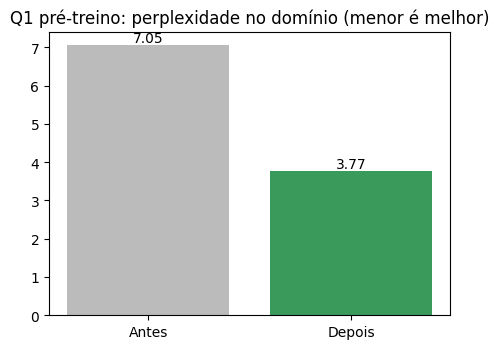

In [14]:
import matplotlib.pyplot as plt
labs = ["Antes", "Depois"]; vals = [lm_antes["perplexidade"], lm_depois["perplexidade"]]
fig, ax = plt.subplots(figsize=(4.5, 3.6))
ax.bar(labs, vals, color=["#bbb", "#3a9a5c"])
ax.set_title("Q1 pré-treino: perplexidade no domínio (menor é melhor)")
for i, v in enumerate(vals): ax.text(i, v, f"{v}", ha="center", va="bottom")
plt.tight_layout(); plt.show()